## <font color="brown">📙&nbsp;&nbsp;Introduction</font>

The travelling salesman problem (TSP) asks the following question: Given a list of cities and the distances between each pair of cities, what is the shortest possible route that visits each city exactly once and returns to the origin city? It is an NP-hard problem in combinatorial optimization, important in operations research and theoretical computer science \[Wikipedia\].

## <font color="brown">🎯&nbsp;&nbsp;Task</font>
The objective of this exercise is to solve the TSP problem for a set of 14 cities in Burma, officially the Republic of the Union of Myanmar. The following vectors give the GPS position of each city.

   LAT = [16.47, 16.47, 20.09, 22.39, 25.23, 22.00, 20.47, 
          17.20, 16.30, 14.05, 16.53, 21.52, 19.41, 20.09]

   LON = [96.10, 94.44, 92.54, 93.37, 97.24, 96.05, 97.02, 
          96.29, 97.38, 98.12, 97.38, 95.59, 97.13, 94.55]
  
**<font color="green">BONUS:</font>** Consider that the distance between two cities is not the Euclidean distance. You have to consider that they are points on the surface of the Earth, which can be considered to be an oblate spheroid.

## <font color="brown">📝&nbsp;&nbsp;Report</font>


1. Provide the better route you found and the shortest path in kilometers. Is it the optimal shortest path ? explain.
2. Describe your fitness function
3. Explain the way you encoded the solution, give a chromosome example.
4. Provide the configuration of the GA you finally used to find your better results: mutation, crossover, population size, type of selection, mutation, crossover used, number of generations. Describe the methodology or experiments performed in order to get your better results.
5. Provide relevant plots of your experiments and explanations.

**Submit your notebook as well**

In [123]:
import numpy as np
from math import radians, cos, sin, sqrt, atan2

# génère la matrice des distances entre toutes les villes en considérant la distance euclidienne
def compute_euclidean_distance_matrix(cities):
    n = len(cities)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            lat1, lon1 = cities[i]
            lat2, lon2 = cities[j]
            dist_matrix[i][j] = sqrt((lat1 - lat2)**2 + (lon1 - lon2)**2)
    return dist_matrix

# génère la matrice des distances entre toutes les villes en considérant la distance réelle (distance de haversine)
def compute_haversine_distance_matrix(cities):
    R = 6371.0  # rayon moyen de la Terre en kilomètres
    n = len(cities)
    dist_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            lat1, lon1 = map(radians, cities[i])
            lat2, lon2 = map(radians, cities[j])

            dlat = lat2 - lat1
            dlon = lon2 - lon1

            a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
            c = 2 * atan2(sqrt(a), sqrt(1 - a))
            distance = R * c

            dist_matrix[i][j] = distance
    return dist_matrix

In [ ]:
LAT = [16.47, 16.47, 20.09, 22.39, 25.23, 22.00, 20.47,
       17.20, 16.30, 14.05, 16.53, 21.52, 19.41, 20.09]
LON = [96.10, 94.44, 92.54, 93.37, 97.24, 96.05, 97.02,
       96.29, 97.38, 98.12, 97.38, 95.59, 97.13, 94.55]
COORDS = list(zip(LAT, LON))

NUM_CITIES = len(COORDS)

euclidean_matrix = compute_euclidean_distance_matrix(COORDS)
haversine_matrix = compute_haversine_distance_matrix(COORDS)

DIST_MATRIX = euclidean_matrix

# exemples
print("Distance Euclidienne entre ville 0 et 1 :", euclidean_matrix[0][2])
print("Distance Haversine entre ville 0 et 1 :", haversine_matrix[0][2])

Distance Euclidienne entre ville 0 et 1 : 5.077203954934244
Distance Haversine entre ville 0 et 1 : 550.6756485857563


In [125]:
import random

# génère un "chromosome" aléatoire (une permutation aléatoire de nombres allant de 0 à nb villes - 1)
def create_random_chromosome(num_cities):
    return random.sample(range(num_cities), num_cities)

# calcule la distance d'une tournée (= un chromosome)
def total_distance(tour):
    distance = 0
    for i in range(len(tour)):
        distance += DIST_MATRIX[tour[i - 1]][tour[i]]
    return distance

# fonction de fitness d'un chromosome (inverse de la distance totale de la tournée)
# correspond à la performance d'un chromosome. cette fonction est essentielle à l'entraînement du modèle.
def fitness(chromosome):
    return 1 / total_distance(chromosome)

# fonction de fitness au format attendu par PyGAD
def fitness_func(ga_instance, solution, solution_idx):
    tour = list(map(int, solution))
    if len(set(tour)) != len(tour):
        return 0
    return fitness(tour)

# exemple d'utilisation
chrom = create_random_chromosome(14)
print("Chromosome:", chrom)
print("Distance totale:", total_distance(chrom))
print("Fitness:", fitness(chrom))

Chromosome: [5, 8, 0, 6, 1, 2, 9, 10, 11, 7, 12, 13, 4, 3]
Distance totale: 6427.977360644937
Fitness: 0.0001555699318610648


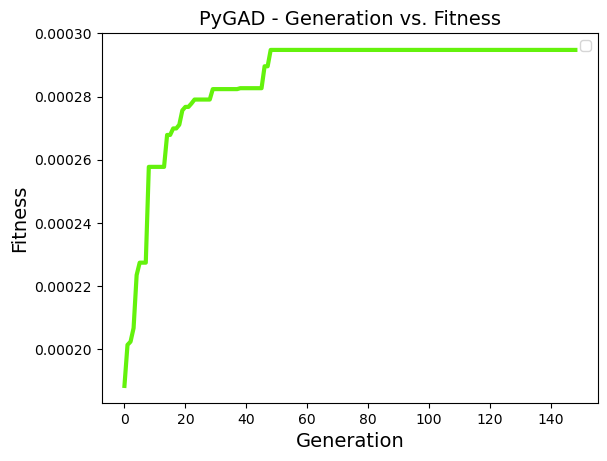

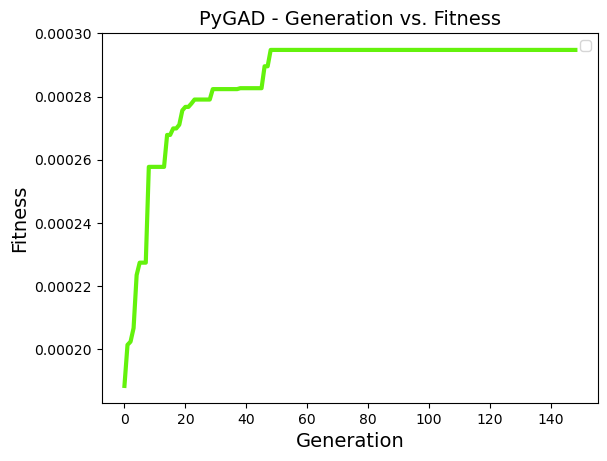

In [126]:
import pygad
import numpy as np

gene_space = list(range(NUM_CITIES))

ga_instance = pygad.GA(
    num_generations=500,
    num_parents_mating=20,
    fitness_func=fitness_func,
    sol_per_pop=50,
    num_genes=NUM_CITIES,
    gene_space=gene_space,
    parent_selection_type="sss",
    keep_parents=5,
    crossover_type="single_point",
    mutation_type="random",
    mutation_percent_genes=10,
    allow_duplicate_genes=False, # important de mettre à False, sinon les solutions générées risquent de passer par plusieurs villes
    stop_criteria=["saturate_100"]
)

ga_instance.run()
ga_instance.plot_fitness()

In [127]:
solution, solution_fitness, _ = ga_instance.best_solution()
best_route = list(map(int, solution))
best_distance = total_distance(best_route)

print("Meilleure route :", best_route)
print("Distance totale :", best_distance, "km")

Meilleure route : [5, 11, 6, 12, 7, 0, 10, 8, 9, 1, 2, 13, 3, 4]
Distance totale : 3452.873753704703 km


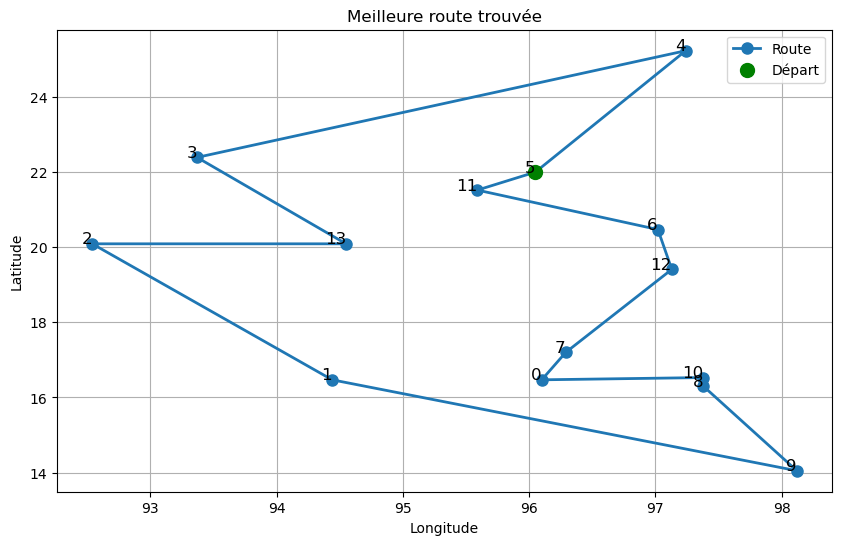

In [128]:
import matplotlib.pyplot as plt

def plot_route(route, coords):
    latitudes = [coords[i][0] for i in route] + [coords[route[0]][0]]
    longitudes = [coords[i][1] for i in route] + [coords[route[0]][1]]

    plt.figure(figsize=(10, 6))
    plt.plot(longitudes, latitudes, 'o-', markersize=8, linewidth=2, label='Route')
    for i, city_idx in enumerate(route):
        plt.text(coords[city_idx][1], coords[city_idx][0], str(city_idx), fontsize=12, ha='right')
    plt.plot(longitudes[0], latitudes[0], 'go', markersize=10, label='Départ')
    plt.title("Meilleure route trouvée")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.grid(True)
    plt.legend()
    plt.show()

# Affichage
plot_route(best_route, COORDS)